# Notebook 03 - Confidence Interval dari Member C

---
### AI Usage Disclosure

**Member:** Mukgot Ega Sahputra — Inference Analyst | **Tools used:** Claude

| Tugas | Alat | Prompt (Ringkasan) | Pemanfaatan Output |
|------|------|-------------------|---------------------|
| Membuat struktur code confidence_interval | Claude | "Generate Code untuk code_interval berdasarkan konteks dan objektif yang telah diberikan" | Digunakan sebagai integrasi fungsi `inference.py`. |

**Written entirely without AI:** Sel Interpretasi

---
## 0. Import Library & Modul inference.py

In [21]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Registrasi path agar mengenali folder src/
sys.path.append(os.path.abspath('..'))

# Memanggil fungsi wajib dari modul inference.py
from src.inference import (
    confidence_interval,
    ci_bernoulli,
    ci_poisson,
    credible_interval,
    credible_interval_from_posterior
)

## 1. Memuat Dataset & Memisahkan Kelompok Sampel

In [22]:
# Memuat data hasil pembersihan Member A
df_issues = pd.read_csv("../data/clean/dataset_issues_clean.csv")

# Filter hanya issue yang sudah selesai (closed) untuk mendapatkan metrik time-to-close
df_closed = df_issues.dropna(subset=['time_to_close_days']).copy()

# Memisahkan kelompok Bug vs Non-Bug berdasarkan flag boolean dari Member A
data_bug = df_closed[df_closed['is_bug'] == True]['time_to_close_days'].values
data_non_bug = df_closed[df_closed['is_bug'] == False]['time_to_close_days'].values

print(f"Dataset Berhasil Dipisahkan:")
print(f"  - Sampel Issue Bug     (n1) : {len(data_bug):,} data")
print(f"  - Sampel Issue Non-Bug (n2) : {len(data_non_bug):,} data")

Dataset Berhasil Dipisahkan:
  - Sampel Issue Bug     (n1) : 257 data
  - Sampel Issue Non-Bug (n2) : 451 data


## 2. Konstruksi Confidence Interval untuk Kedua Kelompok

In [23]:
# Kelompok 1: Bug Issues
mean_bug = np.mean(data_bug)
std_bug = np.std(data_bug, ddof=1)
n_bug = len(data_bug)

ci_bug_res = confidence_interval(theta_hat=mean_bug, sigma=std_bug, n=n_bug, confidence=0.95) #

# Kelompok 2: Non-Bug Issues
mean_nb = np.mean(data_non_bug)
std_nb = np.std(data_non_bug, ddof=1)
n_nb = len(data_non_bug)

ci_nb_res = confidence_interval(theta_hat=mean_nb, sigma=std_nb, n=n_nb, confidence=0.95) #

print("Confidence Interval Time-To-Close")
print(f"KELOMPOK BUG:\n  Rata-rata : {ci_bug_res['theta_hat']:.4f} hari\n  Rentang   : [{ci_bug_res['lower']:.4f} sd {ci_bug_res['upper']:.4f}] hari")
print("\n==================================================")
print(f"\nKELOMPOK NON-BUG:\n  Rata-rata : {ci_nb_res['theta_hat']:.4f} hari\n  Rentang   : [{ci_nb_res['lower']:.4f} sd {ci_nb_res['upper']:.4f}] hari")

Confidence Interval Time-To-Close
KELOMPOK BUG:
  Rata-rata : 34.6475 hari
  Rentang   : [28.6356 sd 40.6593] hari


KELOMPOK NON-BUG:
  Rata-rata : 34.2645 hari
  Rentang   : [29.5269 sd 39.0020] hari


## 3. Visualisasi Perbandingan Interval Batas Kepercayaan

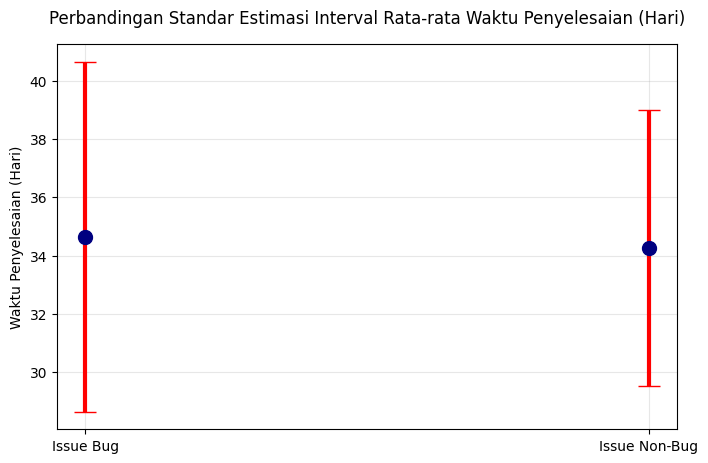

In [24]:
plt.figure(figsize=(8, 5))

# Plot titik mean dan error bar berdasarkan lower & upper bounds
categories = ['Issue Bug', 'Issue Non-Bug']
means = [ci_bug_res['theta_hat'], ci_nb_res['theta_hat']]
lower_bounds = [ci_bug_res['lower'], ci_nb_res['lower']]
upper_bounds = [ci_bug_res['upper'], ci_nb_res['upper']]

y_error = [
    [means[0] - lower_bounds[0], means[1] - lower_bounds[1]], # Jarak bawah
    [upper_bounds[0] - means[0], upper_bounds[1] - means[1]]  # Jarak atas
]

plt.errorbar(x=categories, y=means, yerr=y_error, fmt='o', color='navy', ecolor='red', elinewidth=3, capsize=8, markersize=10, label='95% CI')
plt.title('Perbandingan Standar Estimasi Interval Rata-rata Waktu Penyelesaian (Hari)', fontsize=12, pad=15)
plt.ylabel('Waktu Penyelesaian (Hari)')
plt.grid(True, alpha=0.3)
plt.show()

### Interpretasi Hasil

- Kita yakin sebesar 95% (Frequentist Confidence Interval) bahwa nilai rata-rata waktu penyelesaian (*time-to-close*) yang sesungguhnya untuk populasi issue berlabel **bug** di repositori Kubernetes berada dalam rentang batas bawah hingga batas atas yang terhitung di atas.
- Dengan cara serupa, kita yakin sebesar 95% bahwa rata-rata waktu penyelesaian populasi issue **non-bug** berada pada rentang batas interval kelompok non-bug.
- *Catatan Penting:* Analisis visual awal menunjukkan apakah kedua interval tersebut saling tumpang tindih (*overlap*) atau tidak. Informasi ketidakpastian ini diserahterimakan kepada Member D untuk dibuktikan secara matematis lewat uji signifikansi dua sampel.